ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [1]:
import seaborn as sns # Import the Seaborn library for statistical data visualization, aliasing it as 'sns'
%matplotlib inline   
# Enable inline plotting in Jupyter Notebook so figures render directly below code cells

## Data
Seaborn comes with built-in data sets!

In [ ]:
tips = sns.load_dataset('tips') # Load the built-in 'tips' dataset from Seaborn into a DataFrame

In [3]:
tips.head() # Display the first five rows of the dataset to inspect its structure and features

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\2313113677.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])# Plot a distribution of the total_bill variable with a histogram and kernel density estimate (KDE)


<Axes: xlabel='total_bill', ylabel='Density'>

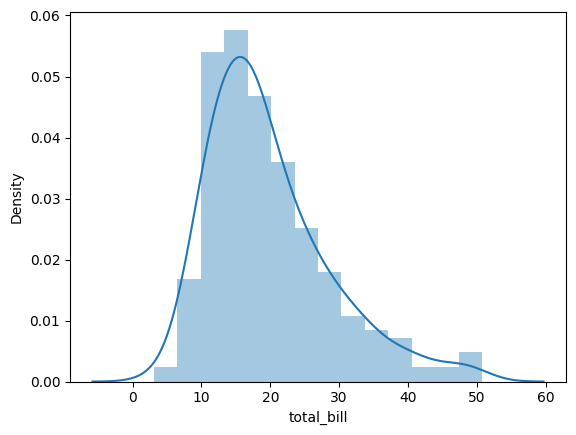

In [4]:
sns.distplot(tips['total_bill'])# Plot a distribution of the total_bill variable with a histogram and kernel density estimate (KDE)
# Safe to ignore warnings

To remove the kde layer and just have the histogram use:

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\4198533040.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'],kde=False,bins=30) # Plot a histogram of total_bill without the KDE curve, using 30 bins


<Axes: xlabel='total_bill'>

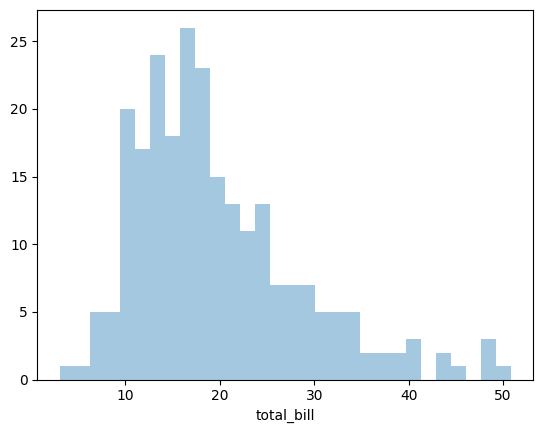

In [ ]:
sns.distplot(tips['total_bill'],kde=False,bins=30) # Plot a histogram of total_bill without the KDE curve, using 30 bins

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

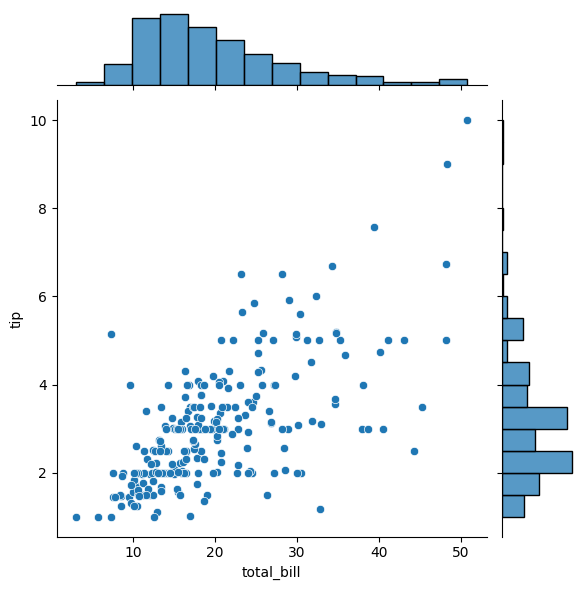

In [7]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')# Create a joint scatter plot showing the relationship between total_bill and tip with marginal distributions

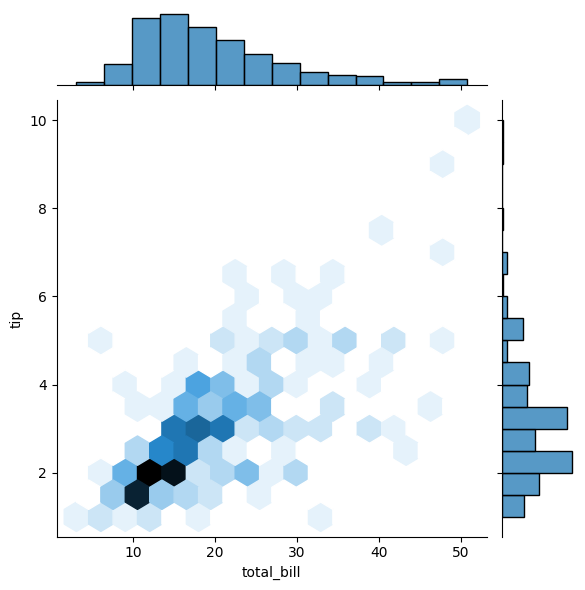

In [8]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')# Create a joint plot with hexagonal binning (hexbin) for total_bill vs tip

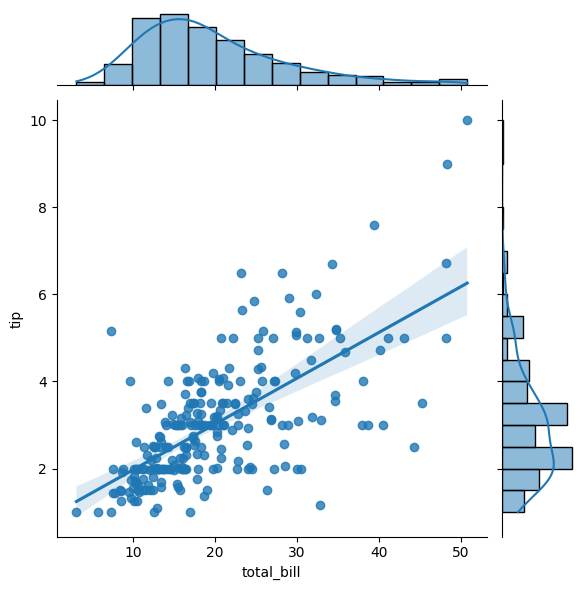

In [ ]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')# Generate a joint plot with a regression line to assess linear correlation between total_bill and tip

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

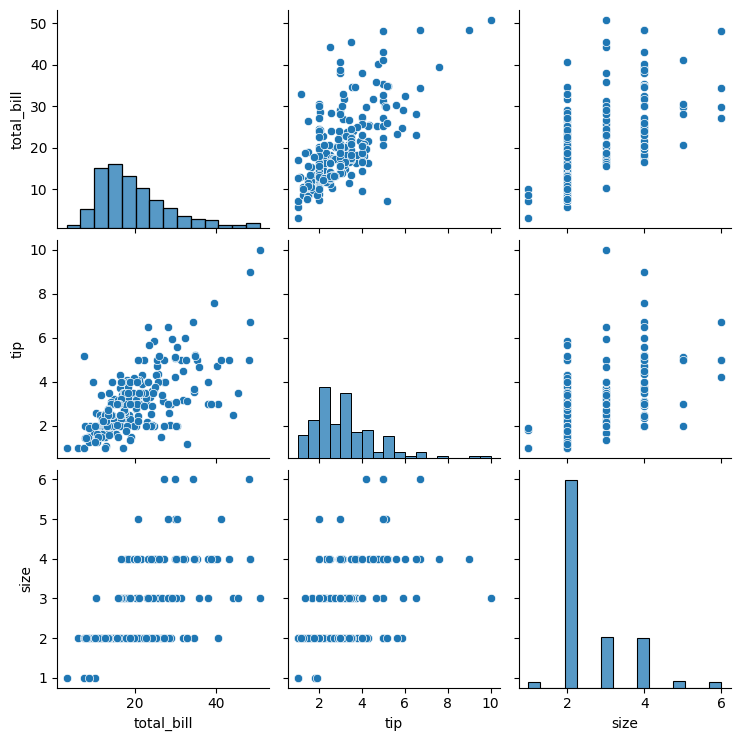

In [ ]:
sns.pairplot(tips)  # Generate a matrix of scatter plots for all numerical columns in the tips dataset

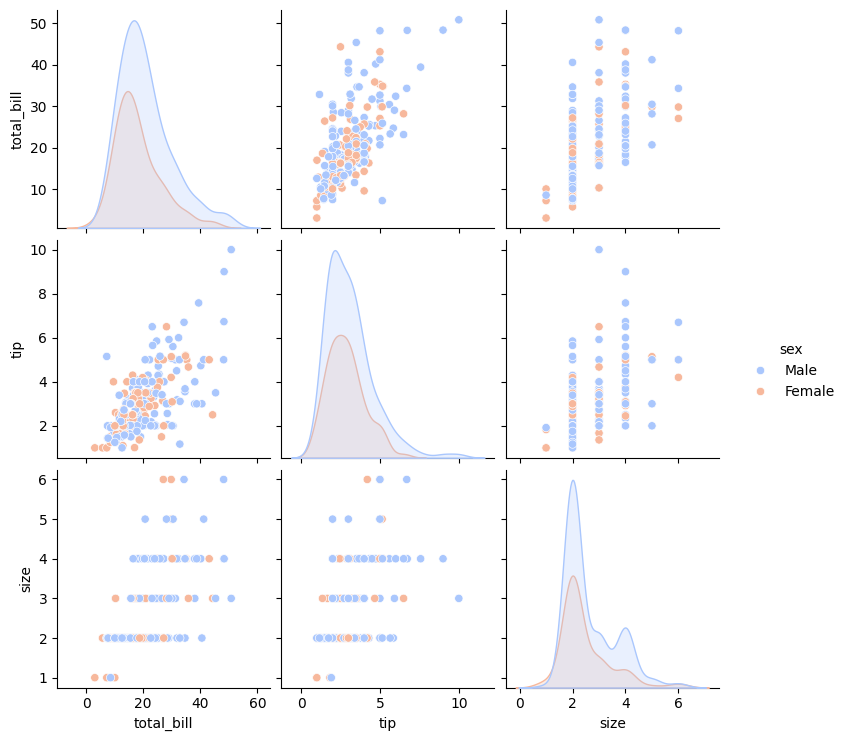

In [11]:
sns.pairplot(tips,hue='sex',palette='coolwarm')# Create pairwise scatter plots colored by the 'sex' column using the 'coolwarm' color palette

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

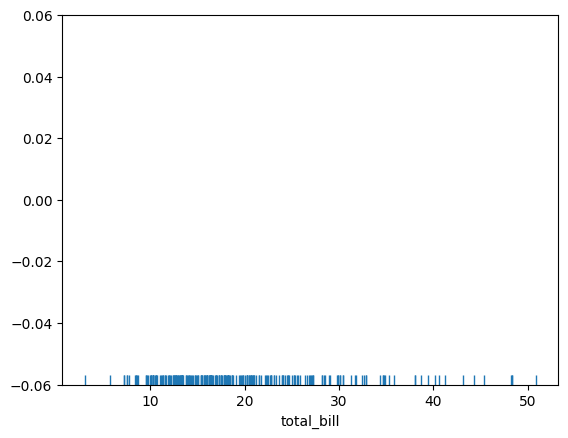

In [ ]:
sns.rugplot(tips['total_bill'])  # Draw a rug plot (small dashes) along the x-axis for each value in 'total_bill' to show data density 

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

(0.0, 1.0)

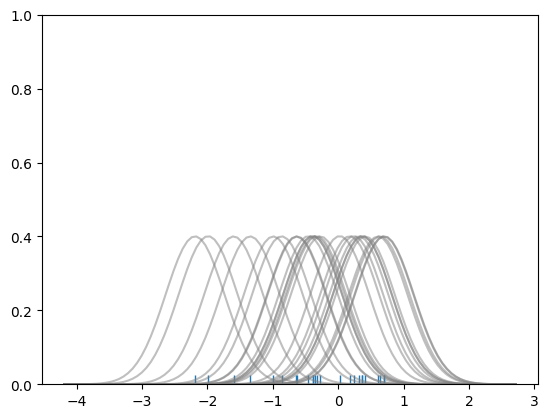

In [21]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np # Import the NumPy library for numerical operations, aliasing it as 'np'
import matplotlib.pyplot as plt # Import the Matplotlib library for plotting, aliasing it as 'plt'
from scipy import stats # Import statistical functions from SciPy for probability density computations

#Create dataset
dataset = np.random.randn(25) # Create a dataset of 25 random numbers drawn from a standard normal distribution

# Create another rugplot
sns.rugplot(dataset); # Plot individual data points along the axis to visualize their distribution density

# Set up the x-axis for the plot
x_min = dataset.min() - 2 # Define the lower x-axis bound with padding below the minimum value
x_max = dataset.max() + 2 # Define the upper x-axis bound with padding above the maximum value

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100) # Create 100 evenly spaced evaluation points across the defined range

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'
# Reference URL for bandwidth selection explanation
bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2 # Compute bandwidth using Silverman’s rule of thumb for KDE smoothing


# Create an empty kernel list
kernel_list = [] # Initialize a list to store individual Gaussian kernel values

# Plot each basis function
for data_point in dataset: # Iterate through each data sample to construct its Gaussian kernel contribution
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis) # Generate the normal distribution PDF centered at the data point
    kernel_list.append(kernel) # Store the computed kernel in the list for potential aggregation
    
    #Scale for plotting
    kernel = kernel / kernel.max() # Normalize the kernel to a maximum value of 1
    kernel = kernel * .4 # Scale the kernel to a height of 0.4 for visual separation
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5) # Plot the scaled kernel as a grey, semi-transparent curve


plt.ylim(0,1) # Set the y-axis limits from 0 to 1 for consistent viewing

Text(0.5, 0.98, 'Sum of the Basis Functions')

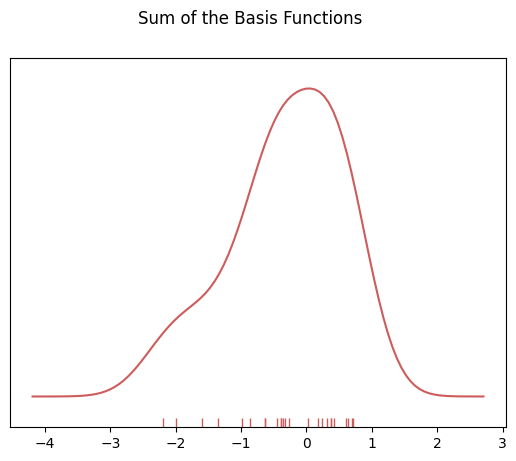

In [23]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0) # Sum all individual kernel functions to obtain the kernel density estimate

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred') # Plot the summed KDE curve along the x-axis using an indianred line

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')  # Re‑plot the original data points as a rug plot in indianred for reference


# Get rid of y-tick marks
plt.yticks([]) # Remove y-axis tick marks for a cleaner density visualization

# Set title
plt.suptitle("Sum of the Basis Functions") # Add a descriptive super title to the figure explaining the KDE aggregation

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

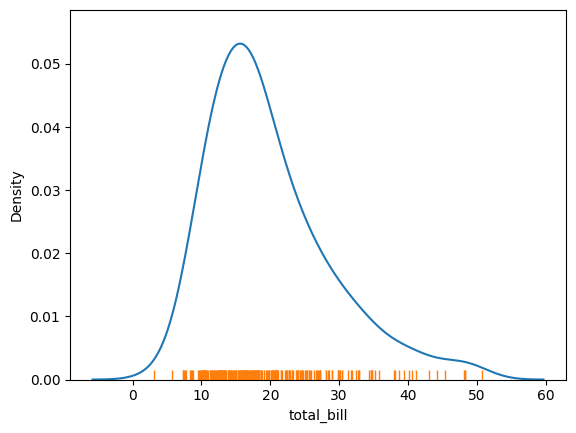

In [24]:
sns.kdeplot(tips['total_bill'])# Plot the Kernel Density Estimate (KDE) to visualize the continuous distribution of total_bill
sns.rugplot(tips['total_bill'])# Overlay a rug plot to display individual total_bill observations along the x-axis

<Axes: xlabel='tip', ylabel='Density'>

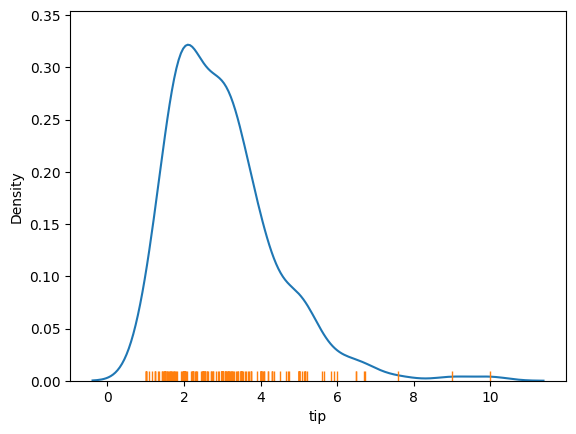

In [27]:
sns.kdeplot(tips['tip'])# Plot the KDE curve for the tip variable to analyze its probability density distribution
sns.rugplot(tips['tip'])# Add a rug plot for each 'tip' data point along the x-axis

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [28]:
import seaborn as sns # Import the Seaborn library for statistical data visualization, aliasing it as 'sns'
%matplotlib inline 
# Ensure that plots are displayed inline within the Jupyter notebook

In [29]:
tips = sns.load_dataset('tips')# Load the built-in "tips" dataset for demonstration and analysis
tips.head()# Display the first five rows to inspect dataset structure and variables

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

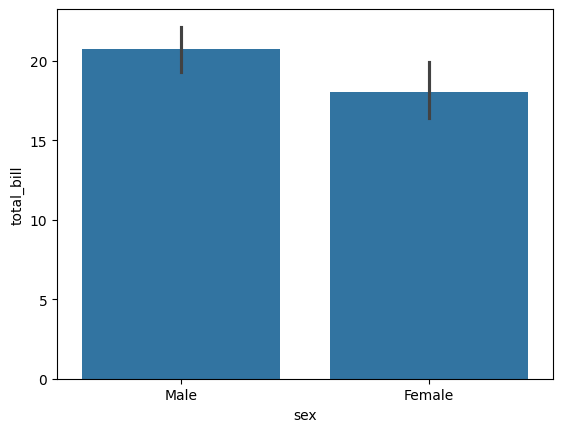

In [30]:
sns.barplot(x='sex',y='total_bill',data=tips) # Create a bar plot showing the mean 'total_bill' for each sex category

In [31]:
import numpy as np # Import the NumPy library for numerical operations, aliasing it as 'np'

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

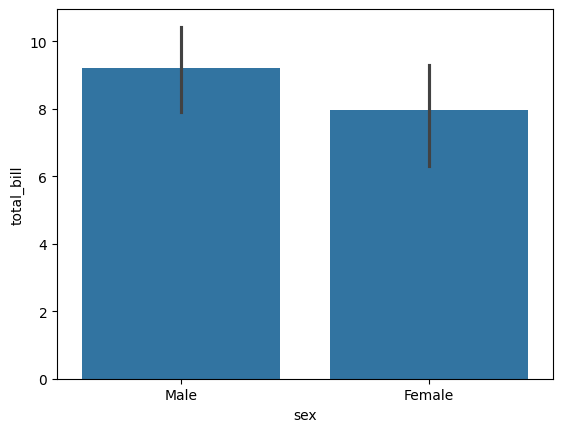

In [33]:
sns.barplot(x='sex',y='total_bill',data=tips,estimator=np.std) # Bar plot using standard deviation as the estimator (instead of the default mean)

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

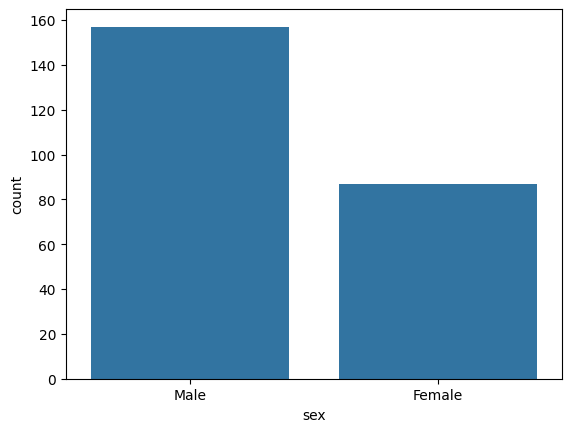

In [34]:
sns.countplot(x='sex',data=tips)# Generate a count plot to show the frequency of each category in the sex variable

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\1838984790.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow') # Create a box plot showing the distribution of total_bill across days with a rainbow color palette


<Axes: xlabel='day', ylabel='total_bill'>

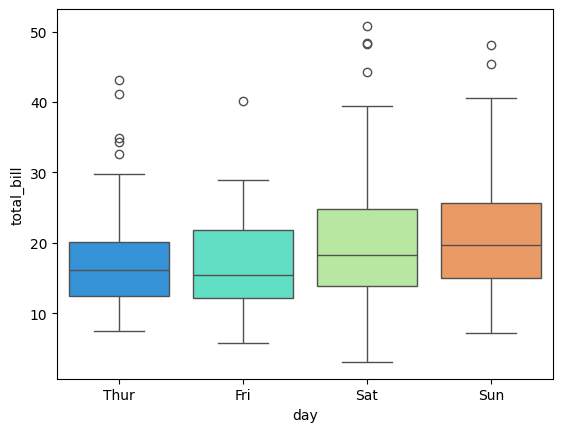

In [35]:
sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow') # Create a box plot showing the distribution of total_bill across days with a rainbow color palette

<Axes: >

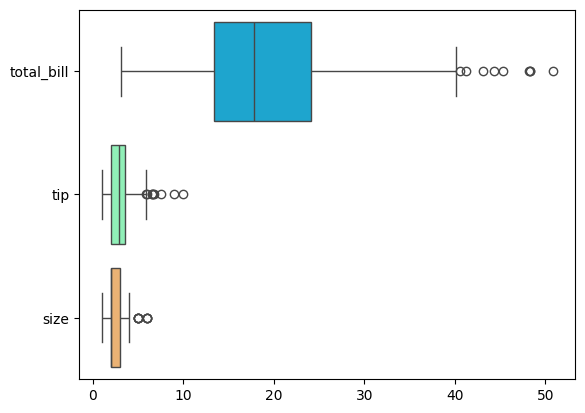

In [36]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips,palette='rainbow',orient='h')# Generate horizontal box plots for all numerical columns in the dataset

<Axes: xlabel='day', ylabel='total_bill'>

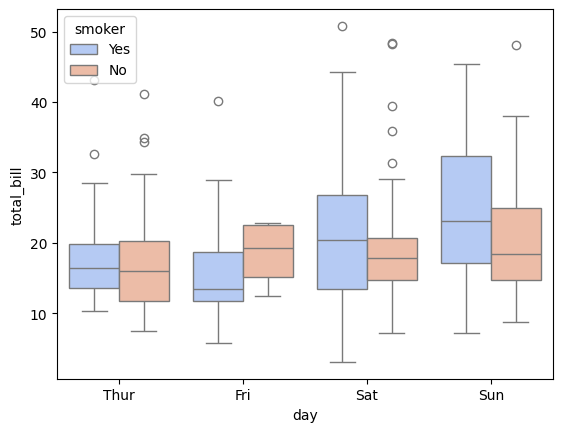

In [37]:
sns.boxplot(x="day", y="total_bill", hue="smoker",data=tips, palette="coolwarm")# Box plot of total_bill by day, further grouped by smoker status with coolwarm colors

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\581391773.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow') # Create a violin plot to show distribution of total_bill per day with rainbow palette


<Axes: xlabel='day', ylabel='total_bill'>

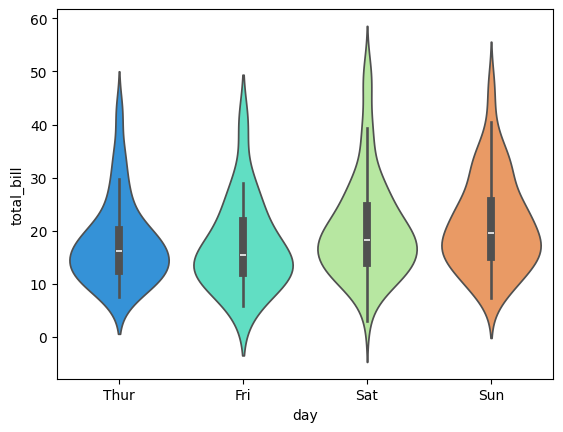

In [38]:
sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow') # Create a violin plot to show distribution of total_bill per day with rainbow palette

<Axes: xlabel='day', ylabel='total_bill'>

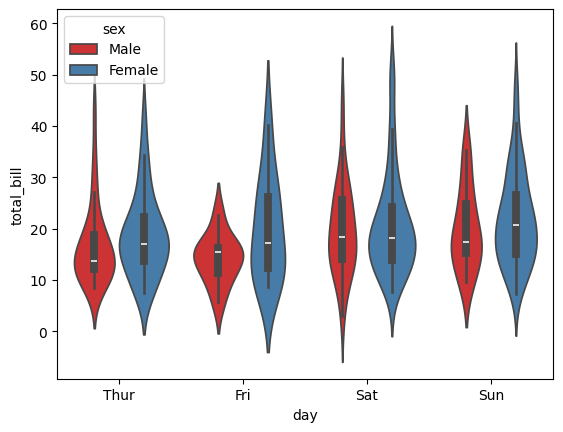

In [40]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',palette='Set1')# Violin plot of total_bill by day, separated by sex with Set1 color palette

<Axes: xlabel='day', ylabel='total_bill'>

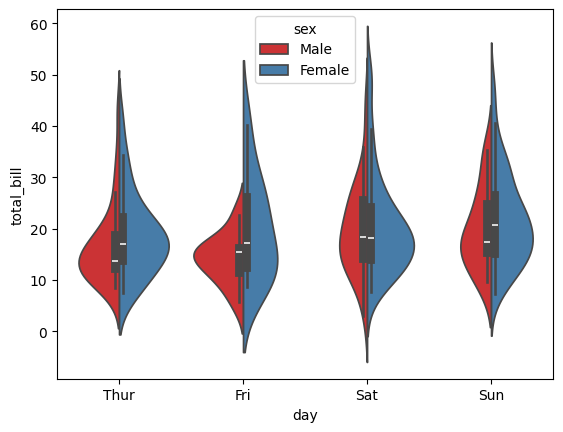

In [42]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',split=True,palette='Set1') # Generate split violin plots to display male and female distributions within the same violin

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\3580856303.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow') # Create a strip plot (scatter plot) of total_bill per day with rainbow colors


<Axes: xlabel='day', ylabel='total_bill'>

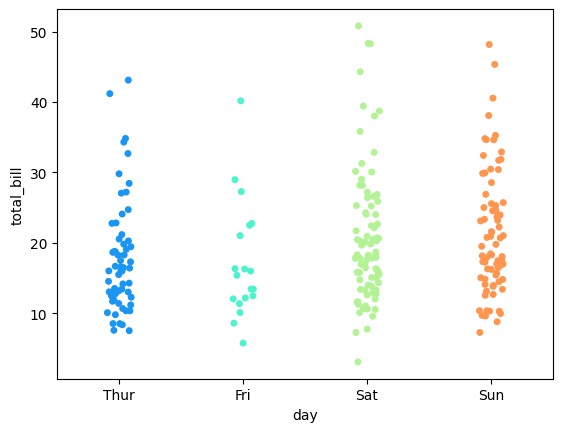

In [44]:
sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow') # Create a strip plot (scatter plot) of total_bill per day with rainbow colors

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\157698564.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow') # Add jitter to reduce overlap and improve visibility of individual observations


<Axes: xlabel='day', ylabel='total_bill'>

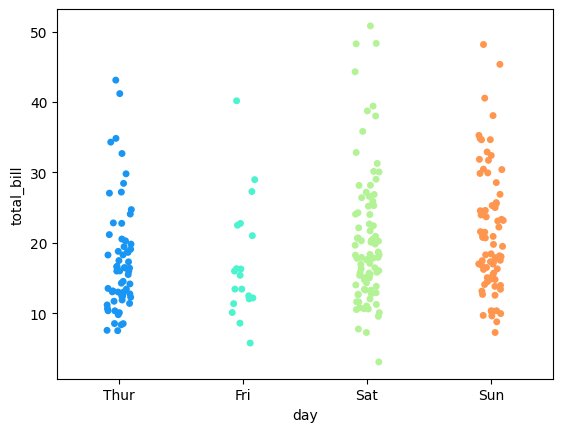

In [46]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow') # Add jitter to reduce overlap and improve visibility of individual observations

<Axes: xlabel='day', ylabel='total_bill'>

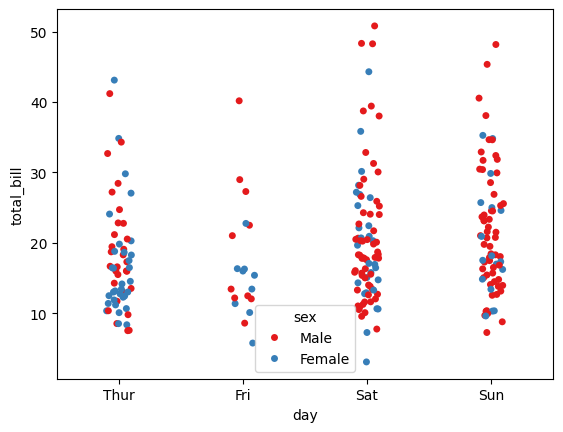

In [49]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1') # Strip plot with jitter, colored by sex, with Set1 palette

<Axes: xlabel='day', ylabel='total_bill'>

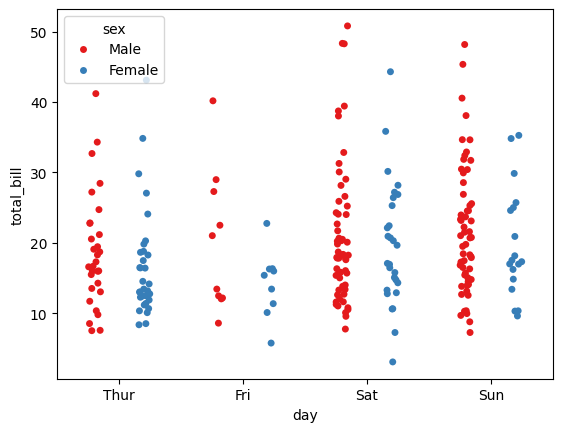

In [51]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1',dodge=True) # Separate overlapping categorical points horizontally using dodge for clearer comparison

<Axes: xlabel='day', ylabel='total_bill'>

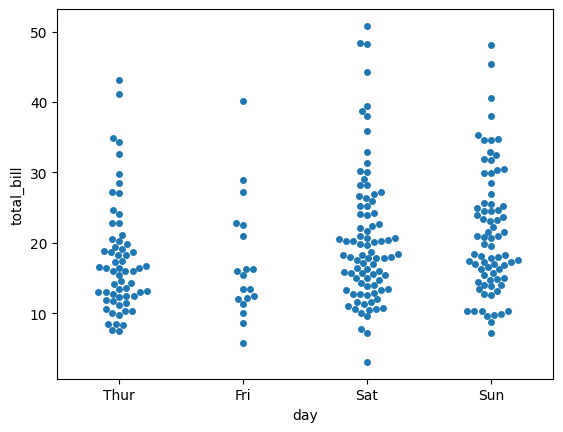

In [52]:
sns.swarmplot(x="day", y="total_bill", data=tips) # Generate a swarm plot that arranges points to avoid overlap while preserving distribution structure

### Combining Categorical Plots

C:\Users\hbq20\AppData\Local\Temp\ipykernel_22716\3001236609.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="tip", y="day", data=tips,palette='rainbow') # Create horizontal violin plots to visualize the distribution of tip amounts across days


<Axes: xlabel='tip', ylabel='day'>

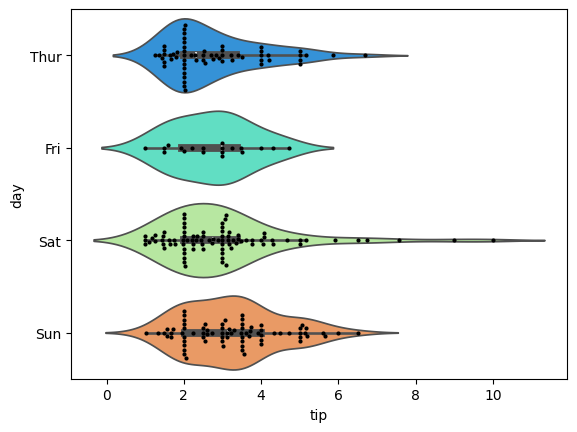

In [53]:
sns.violinplot(x="tip", y="day", data=tips,palette='rainbow') # Create horizontal violin plots to visualize the distribution of tip amounts across days
sns.swarmplot(x="tip", y="day", data=tips,color='black',size=3) # Overlay a swarm plot to display individual observations without overlap

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

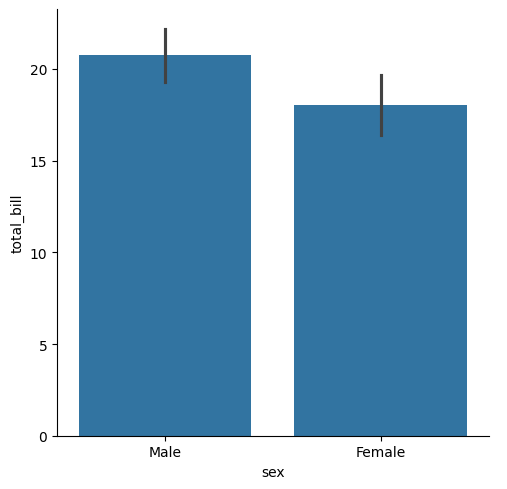

In [54]:
sns.catplot(x='sex',y='total_bill',data=tips,kind='bar')# Generate a categorical bar plot showing mean total_bill grouped by sex

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [55]:
import seaborn as sns # Import the Seaborn library for statistical data visualization, aliasing it as 'sns'
%matplotlib inline
# Enable inline rendering of plots within a Jupyter Notebook

In [56]:
flights = sns.load_dataset('flights') # Load the built-in flights dataset containing monthly passenger counts

In [57]:
tips = sns.load_dataset('tips') # Reload the tips dataset for correlation and heatmap analysis

In [58]:
tips.head()# Display the first five rows of the tips dataset

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [59]:
flights.head()# Display the first five rows of the flights dataset

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [60]:
tips.head() # Reconfirm the structure of the tips dataset before analysis

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Matrix form for correlation data
tips.corr() # Compute the pairwise correlation matrix for numerical variables in the dataset

In [ ]:
sns.heatmap(tips.corr()) # Visualize the correlation matrix as a heatmap

In [ ]:
sns.heatmap(tips.corr(),cmap='coolwarm',annot=True) # Render the correlation heatmap with a diverging colormap and numeric annotations

Or for the flights data:

In [ ]:
flights.pivot_table(values='passengers',index='month',columns='year') # Create a pivot table restructuring passenger counts by month and year

In [ ]:
pvflights = flights.pivot_table(values='passengers',index='month',columns='year') # Store the pivoted passenger data into a new DataFrame for visualization
sns.heatmap(pvflights) # Plot a heatmap of passenger traffic across months and years

In [ ]:
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1) # Enhance the heatmap with a custom colormap and gridlines for improved readability

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

In [ ]:
sns.clustermap(pvflights) # Generate a clustered heatmap that hierarchically groups similar rows and columns

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

In [ ]:
# More options to get the information a little clearer like normalization
sns.clustermap(pvflights,standard_scale=1) # Apply column-wise standardization to normalize values before clustering

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [ ]:
import seaborn as sns # Import the Seaborn library for statistical data visualization, aliasing it as 'sns'
%matplotlib inline
# Enable inline display of plots within a Jupyter Notebook

In [ ]:
tips = sns.load_dataset('tips') # Load the built-in tips dataset for regression analysis

In [ ]:
tips.head() # Display the first five rows to inspect dataset features

## lmplot()

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips) # Create a scatter plot with a linear regression line between total_bill and tip

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex') # Add categorical color separation based on sex

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm') # Apply a custom color palette to distinguish categories

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='sex') # Create separate regression plots in different columns for each sex category

In [ ]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time",data=tips) # Create a multi-facet grid splitting plots by sex (rows) and time (columns)

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm') # Generate regression plots by day with color encoding for sex

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm', aspect=0.6,height=8) # Adjust subplot aspect ratio and height for improved layout and readability

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes